In [1]:
import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
from langgraph.graph import StateGraph
from langchain_groq import ChatGroq
llm = ChatGroq(
    model = "llama-3.3-70b-versatile"
)
res=llm.invoke("Hi")
res

AIMessage(content="It's nice to meet you. Is there something I can help you with, or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 36, 'total_tokens': 60, 'completion_time': 0.053310948, 'completion_tokens_details': None, 'prompt_time': 0.000983648, 'prompt_tokens_details': None, 'queue_time': 0.010042716, 'total_time': 0.054294596}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9511-69b3-7e62-b4ae-2d8f514703a5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 24, 'total_tokens': 60})

In [3]:
def add (a: int, b: int)-> int:
    #providing docstring is necessary for the function to be used as a tool in langgraph
    '''Add a and b
    Args: 
        a (int): first int
        b (int): second int
    
    Returns: 
        int: sum of a and b
    '''
    return a+b 


In [4]:
from langchain.tools import tool
from langchain_core.messages import HumanMessage
llm_with_tool = llm.bind_tools([add])
response =llm_with_tool.invoke([HumanMessage(content="What is 2+3?")])

In [5]:
response.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 3},
  'id': 'ag82m1zxs',
  'type': 'tool_call'}]

In [6]:
from typing_extensions import TypedDict, List
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated
class State(TypedDict):
    #can pass any messages HmanMessage, AIMessage, SystemMessage etc
    messages: Annotated[List[AnyMessage], add_messages]

In [7]:
def llm_tool(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

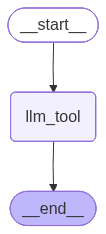

In [8]:
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, display

graph = StateGraph(State)
graph.add_node("llm_tool", llm_tool)

graph.add_edge(START, "llm_tool")
graph.add_edge("llm_tool", END)

graph = graph.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
messages = graph.invoke({"messages": [HumanMessage(content="What is 2+3?")]})

In [11]:
from pprint import pprint 
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2+3?
================================== Ai Message ==================================
Tool Calls:
  add (xvdjezcw6)
 Call ID: xvdjezcw6
  Args:
    a: 2
    b: 3


In [12]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [13]:
tools = [add]

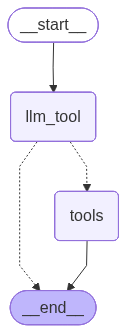

In [18]:
graph = StateGraph(State)

graph.add_node("llm_tool", llm_tool)
graph.add_node("tools", ToolNode(tools))


graph.add_edge(START, "llm_tool")
graph.add_conditional_edges(
    "llm_tool",
    tools_condition,  # If the latest message from assistant is a tool call -> routes to tools, else routes to END
    {"tools": "tools", END: END}
)
graph.add_edge("tools", END)
graph = graph.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
messages = graph.invoke({"messages": [HumanMessage(content="What is 2+3?")]})

In [21]:
from pprint import pprint 
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2+3?
================================== Ai Message ==================================
Tool Calls:
  add (n6mchcfc4)
 Call ID: n6mchcfc4
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: add

5
